## Part 5 Gather data: H(pose), (Rays C: size M, R), (Sigma (Hidden state): size (M, R, N))

## import libraries

In [1]:
"""
Re‑creates your current world + camera demo and opens a matplotlib window.
Run:  python -m examples.demo_world
"""
import numpy as np
import torch

from nerflab import (
    Intrinsics, Camera,
    CFG, pose_H, make_pose_cases, 
    viz_sigma_heatmap, viz_sigma_scatter, load_world
)
from nerflab.learning.io import query_density_field
from nerflab.learning.forward_sigma import nerf_opacity
import numpy as np



# TODO
from nerflab.learning.gathering_data import gather_and_save


ImportError: cannot import name 'query_density_field' from 'nerflab.learning.ops' (/home/elyamani/Main/programming/nerf-lab/nerflab/learning/ops.py)

In [2]:
# build preset dictionary
cases = make_pose_cases(axis_dist=3)

# pick a view (e.g., diagonal)
H_wc = pose_H(cases["+Z"])  
# H_wc = np.eye(4)
print(H_wc)

[[ 1.  0. -0.  0.]
 [-0.  1. -0.  0.]
 [ 0.  0.  1.  3.]
 [ 0.  0.  0.  1.]]


In [3]:
O_w, D_w = get_batch_rays(H_wc)
# O_w = torch.from_numpy(O_w)
# D_w = torch.from_numpy(D_w)
t, delta, pts = stratified_samples_batch(O_w, D_w)
print("points shape:", pts.shape)
print(delta.shape)
print(t.shape)

points shape: torch.Size([4096, 20, 3])
torch.Size([4096, 20])
torch.Size([4096, 20])


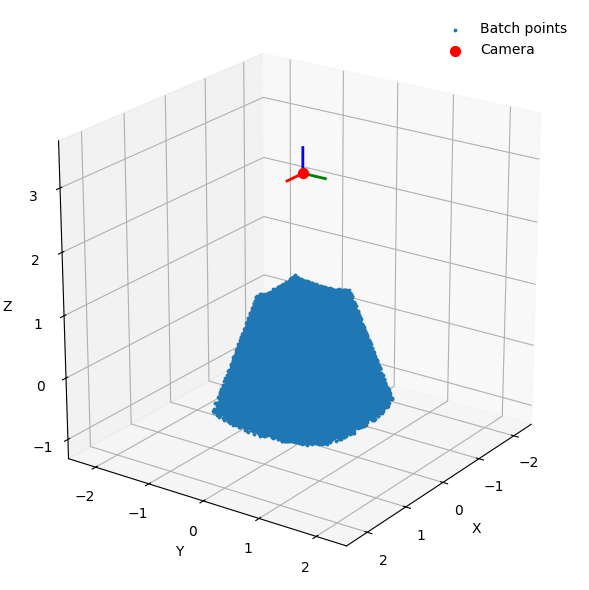

In [4]:
plot_cloud_batch_with_camera(pts, H_wc)

In [5]:
def sigma_from_world(world, pts: np.ndarray, max_sigma = 10e6) -> np.ndarray:
    """
    Vectorized sigma query.

    Parameters
    ----------
    world : World
        Must expose world.density(x,y,z) -> float (your code already uses it).
    pts   : (R,N,3) array
        Sampled 3D points.

    Returns
    -------
    sigma : (R,N) float32
    """
    R, N, _ = pts.shape
    P = pts.reshape(-1, 3)                       # (R*N,3)
    # evaluate density per point
    sig = np.array([world.density(*p) for p in P], dtype=np.float32)
    # 1) Replace NaN/Inf
    sig = np.nan_to_num(sig, nan=0.0, posinf=max_sigma, neginf=0.0).astype(np.float32)
    # 2) Ensure non-negative
    sig = np.clip(sig, 0.0, max_sigma)

    return sig.reshape(R, N)

In [6]:
world = load_world('../data/world.json')
sig = sigma_from_world(world, pts)

In [7]:
# — example usage —

# assume you already have:
#  poses: torch.Tensor[M,4,4]
#  intrinsics: dict
my_poses = [H_wc]
gather_and_save(
  poses       = my_poses, 
  output_path = "nerf_simplified_data.h5"
  )


AttributeError: 'Tensor' object has no attribute 'astype'